# Project Context & Objective

Analisis ini dirancang sebagai panduan teknis bagi tim AI dalam membangun model TF Transaction Classifier. Mengingat proyek Finsight berfokus pada Decision Engine, EDA ini bertujuan untuk membedah karakteristik data teks guna menentukan strategi preprocessing, penanganan ambiguitas, dan pemilihan algoritma yang paling efisien untuk klasifikasi transaksi otomatis.

# Business Understanding

### Latar Belakang

FinSight merupakan platform manajemen keuangan berbasis AI untuk membantu pengguna melakukan pencatatan transaksi secara otomatis, memberikan peringatan anggaran (budget alert), serta menyediakan rekomendasi penghematan.

# Data Understanding

### Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install wordcloud

### Load Dataset

In [3]:
df = pd.read_csv('/content/data_final_3.csv')

### Dataset Overview

In [4]:
df.head()

,deskripsi,category,source,deskripsi_clean
0,susu,makanan,df1,susu
1,makan malam bersama teman,hiburan,df1,makan malam teman
2,tagihan air,tagihan,df1,tagihan air
3,kelas yoga,kesehatan,df1,kelas yoga
4,bunga,belanja,df1,bunga


In [5]:
df.shape

(3583, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3583 entries, 0 to 3582
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   deskripsi        3583 non-null   object
 1   category         3583 non-null   object
 2   source           3583 non-null   object
 3   deskripsi_clean  3577 non-null   object
dtypes: object(4)
memory usage: 112.1+ KB


In [7]:
df.describe(include='all')

,deskripsi,category,source,deskripsi_clean
count,3583,3583,3583,3577
unique,1066,7,4,1041
top,kelas yoga,belanja,synthetic,sepatu
freq,22,690,2046,22


#### Insight

Dataset ini memiliki total 3.583 entri dengan empat kolom kategorikal, di mana kolom deskripsi_clean menunjukkan adanya 6 nilai kosong yang perlu ditangani sebelum tahap pemodelan lebih lanjut. Dari total data yang tersedia, kategori "belanja" muncul sebagai label yang paling dominan (690 kali), sementara sebagian besar sumber data berasal dari kategori "synthetic" (2.046 entri). Selain itu, terdapat variasi yang cukup tinggi pada deskripsi transaksi dengan 1.066 nilai unik, namun kemunculan kata "sepatu" dan "kelas yoga" sebagai nilai yang paling sering muncul mengindikasikan adanya pola pengeluaran yang spesifik dalam dataset ini. Proses pembersihan teks pada kolom deskripsi_clean terlihat berhasil menyederhanakan input asli, seperti mengubah "makan malam bersama teman" menjadi "makan malam teman", yang akan sangat membantu dalam meningkatkan efisiensi ekstraksi fitur nantinya.

# Data Wrangling

### Gathering Data

Dataset transaksi dikumpulkan dari beberapa sumber:
- dataset transaksi manual,
- dataset sintetik,
- hasil augmentasi data.

### Assessing Data

#### Missing value

In [8]:
df.isnull().sum()

,0
deskripsi,0
category,0
source,0
deskripsi_clean,6


In [9]:
df[df['deskripsi_clean'].isnull()]

,deskripsi,category,source,deskripsi_clean
1549,tahu,makanan,synthetic,NaN
3268,lain lain,lainnya,synthetic,NaN
3270,macam macam,lainnya,synthetic,NaN
3381,lain lain,lainnya,synthetic,NaN
3383,macam macam,lainnya,synthetic,NaN
3578,lain lain,lainnya,augmentasi,NaN


#### Insight:
Ditemukan 6 data kosong pada kolom deskripsi_clean yang disebabkan oleh proses filtering kata-kata pendek atau stopwords (misal: "tahu", "lain lain").

#### Category distribution

In [10]:
df['category'].value_counts()

,count
category,
belanja,690
makanan,652
tagihan,594
hiburan,563
kesehatan,455
transportasi,423
lainnya,206


#### Insight

Dataset ini memiliki keseimbangan kategori yang cukup baik (well-balanced) untuk keperluan klasifikasi, dengan kategori "belanja" (690) dan "makanan" (652) sebagai kontributor utama. Rentang jumlah data antar kategori utama seperti "tagihan" (594), "hiburan" (563), "kesehatan" (455), dan "transportasi" (423) tidak menunjukkan adanya gap yang ekstrem, sehingga risiko class imbalance yang berat dapat diminimalisir. Namun, kategori "lainnya" yang hanya berjumlah 206 entri perlu diperhatikan lebih lanjut karena memiliki volume data paling sedikit, yang berpotensi membuat model lebih sulit dalam mengenali pola transaksi yang bersifat umum atau tidak terdefinisi secara spesifik. Secara keseluruhan, struktur data ini sudah sangat mumpuni untuk melatih model dalam mengategorikan catatan keuangan secara otomatis.

#### Dataset Variability & Duplication Analysis

In [11]:
duplicate_data = df[df.duplicated()]

duplicate_data.head(20)

,deskripsi,category,source,deskripsi_clean
5,bunga,belanja,df1,bunga
11,perbaikan mobil,transportasi,df1,perbaikan mobil
23,susu,makanan,df1,susu
27,makanan cepat saji,makanan,df1,makanan cepat saji
28,sepatu,belanja,df1,sepatu
29,angkutan umum,transportasi,df1,angkutan umum
31,permainan anak-anak,belanja,df1,permainan anakanak
32,perhiasan,belanja,df1,perhiasan
33,ruu gas,tagihan,df1,ruu gas
34,kelas yoga,kesehatan,df1,kelas yoga


In [12]:
text_duplicate = df.duplicated(
    subset=['deskripsi_clean', 'category']
).sum()

text_duplicate

np.int64(2538)

In [13]:
duplicate_percentage = (
    text_duplicate / len(df)
) * 100

duplicate_percentage

np.float64(70.83449623220764)

#### Insight

Tingkat duplikasi yang sangat tinggi dalam dataset, di mana terdapat 2.538 baris data yang memiliki kombinasi deskripsi_clean dan category yang sama, atau setara dengan kurang lebih 70.83% dari total keseluruhan data. Visualisasi sampel, di mana entri seperti "susu", "perhiasan", dan "tiket pesawat" muncul berulang kali dengan label kategori yang identik. Tingginya angka redundansi ini mengindikasikan bahwa meskipun volume data terlihat besar secara kuantitas, variasi informasi yang unik di dalamnya sebenarnya cukup terbatas. Oleh karena itu, perlu dilakukan evaluasi apakah data duplikat ini akan dipertahankan untuk memperkuat bobot fitur tertentu atau justru dihapus (drop duplicates) guna mencegah model mengalami overfitting terhadap pola-pola kalimat yang muncul terlalu sering.

#### Unique category

In [14]:
df['category'].unique()

array(['makanan', 'hiburan', 'tagihan', 'kesehatan', 'belanja',
       'transportasi', 'lainnya'], dtype=object)

#### Insight

Dataset ini mengklasifikasikan transaksi ke dalam 7 kategori unik, yaitu makanan, hiburan, tagihan, kesehatan, belanja, transportasi, dan lainnya. Cakupan kategori ini sudah cukup komprehensif untuk merepresentasikan pengeluaran harian umum, sehingga model nantinya dapat belajar membedakan kebutuhan pokok seperti "makanan" dan "tagihan" dari kebutuhan sekunder seperti "hiburan" atau "belanja" secara spesifik.

#### Category Variability Analysis

In [15]:
for category in df['category'].unique():

    total = len(df[df['category']==category])

    unique = len(
        df[df['category']==category]
        .drop_duplicates(subset=['deskripsi_clean'])
    )

    print(f'''
Kategori: {category}
Total Data: {total}
Unique Data: {unique}
''')


Kategori: makanan
Total Data: 652
Unique Data: 214


Kategori: hiburan
Total Data: 563
Unique Data: 150


Kategori: tagihan
Total Data: 594
Unique Data: 148


Kategori: kesehatan
Total Data: 455
Unique Data: 132


Kategori: belanja
Total Data: 690
Unique Data: 185


Kategori: transportasi
Total Data: 423
Unique Data: 146


Kategori: lainnya
Total Data: 206
Unique Data: 70



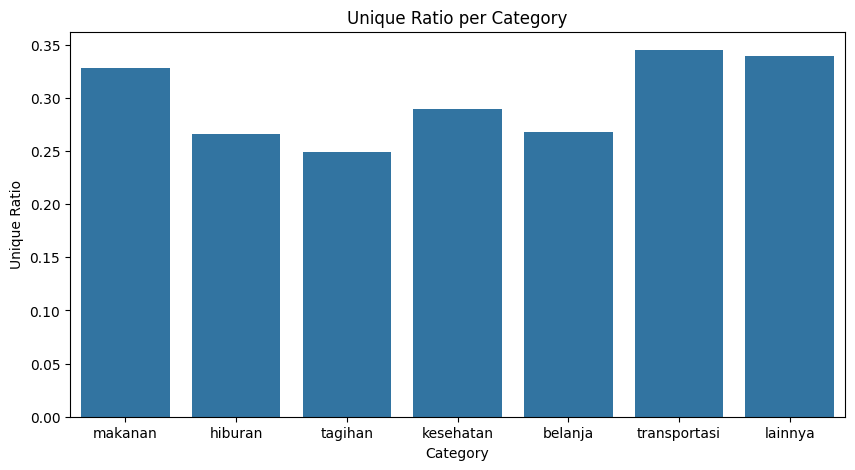

In [16]:
categories = []
ratios = []

for category in df['category'].unique():

    total = len(
        df[df['category'] == category]
    )

    unique = len(
        df[df['category'] == category]
        .drop_duplicates(subset=['deskripsi_clean'])
    )

    ratio = unique / total

    categories.append(category)
    ratios.append(ratio)

variability_df = pd.DataFrame({
    'category': categories,
    'unique_ratio': ratios
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=variability_df,
    x='category',
    y='unique_ratio'
)

plt.title('Unique Ratio per Category')
plt.xlabel('Category')
plt.ylabel('Unique Ratio')

plt.show()

#### Insight

Analisis rasio data unik menunjukkan bahwa kategori "transportasi" dan "makanan" memiliki variabilitas deskripsi yang paling tinggi dibandingkan kategori lainnya. Meskipun kategori "belanja" memiliki total data terbanyak (690 entri), rasio keunikannya cenderung lebih rendah, yang mengindikasikan banyaknya pola deskripsi yang berulang pada kategori tersebut. Sebaliknya, kategori "tagihan" memiliki unique ratio terendah (sekitar 0.25), menunjukkan bahwa teks dalam kategori ini sangat terprediksi dan konsisten, yang biasanya mempermudah model dalam melakukan klasifikasi. Perbedaan tingkat keunikan antar kategori ini sangat penting diperhatikan karena kategori dengan rasio unik tinggi akan membutuhkan fitur teks yang lebih kaya agar model tidak gagal mengenali variasi kata saat fase pengujian nantinya.

### Data Cleaning

#### Drop missing

In [17]:
words_to_save = ['tahu']

mask = (df['deskripsi_clean'].isna()) & (df['deskripsi'].isin(words_to_save))
df.loc[mask, 'deskripsi_clean'] = df.loc[mask, 'deskripsi']

df.dropna(subset=['deskripsi_clean'], inplace=True)

print(f"Jumlah baris setelah filter selektif: {len(df)}")
print(df.isnull().sum())

Jumlah baris setelah filter selektif: 3578
deskripsi          0
category           0
source             0
deskripsi_clean    0
dtype: int64


#### Insight

Tahap filtrasi selektif ini berhasil menangani masalah missing values pada kolom deskripsi_clean secara efisien dengan menyelamatkan kata kunci penting seperti "tahu" sebelum menghapus baris yang benar-benar kosong. Hasil akhirnya menunjukkan dataset yang kini sepenuhnya bersih dari nilai null di seluruh kolom, dengan mempertahankan total 3.578 baris data. Secara teknis, langkah ini krusial untuk memastikan integritas data terpenuhi sehingga model klasifikasi teks nantinya tidak akan mengalami error atau bias akibat input yang tidak lengkap.

#### Create unique dataset

In [18]:
df_unique = df.drop_duplicates(
    subset=['deskripsi_clean', 'category']
)

df_unique.shape

(1044, 4)

#### Insight

Dataset unik dibuat untuk menganalisis variasi dan kompleksitas transaksi tanpa pengaruh duplicate data.

Namun, sebagian besar EDA tetap menggunakan dataset asli untuk mempertahankan distribusi transaksi aktual pengguna, karena transaksi finansial secara alami bersifat repetitive.

# Exploratory Data Analysis (EDA)

#### Category Distribution Analysis

In [19]:
df['deskripsi_clean'].value_counts().head(20)

,count
deskripsi_clean,
sepatu,22
kelas yoga,22
obat,22
tiket pesawat,22
elektronik,20
video game,20
keanggotaan gimnasium,20
buahbuahan,20
sabun,20


#### Insight

Analisis pada kolom deskripsi_clean menunjukkan pola distribusi frekuensi yang sangat seragam, di mana sebagian besar kata kunci seperti "sepatu", "kelas yoga", hingga "top up game" memiliki jumlah kemunculan yang hampir identik (berkisar antara 20 hingga 22 kali). Fenomena ini mengonfirmasi bahwa dataset memiliki struktur yang sangat teratur, yang kemungkinan besar disebabkan oleh penggunaan data synthetic yang telah diatur distribusinya. Bagi model NLP, konsistensi frekuensi kata ini menguntungkan karena memberikan basis data yang stabil untuk mempelajari setiap label, namun kita harus tetap waspada terhadap potensi overfitting karena variasi teks yang relatif terbatas pada kata-kata kunci utama tersebut.

#### Deep Dive Kategori "Lainnya"

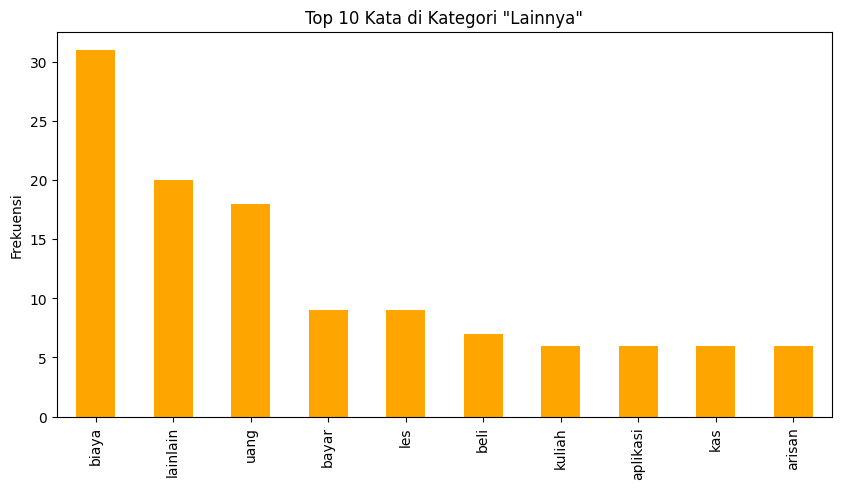

In [20]:
df_lainnya = df[df['category'] == 'lainnya']

top_words_lainnya = pd.Series(' '.join(df_lainnya['deskripsi_clean']).split()).value_counts().head(10)

plt.figure(figsize=(10,5))
top_words_lainnya.plot(kind='bar', color='orange')
plt.title('Top 10 Kata di Kategori "Lainnya"')
plt.ylabel('Frekuensi')
plt.show()

#### Insight

Visualisasi 10 kata teratas dalam kategori "Lainnya" menunjukkan bahwa kata "biaya", "lainlain", dan "uang" menjadi token yang paling sering muncul, yang mengindikasikan bahwa kategori ini berfungsi sebagai penampung untuk transaksi yang bersifat umum atau kurang spesifik secara semantik. Menariknya, terdapat kata kunci yang lebih spesifik seperti "les", "kuliah", dan "arisan" yang sebenarnya memiliki potensi untuk dikelompokkan ke dalam kategori baru (misalnya: Pendidikan atau Sosial) guna meningkatkan presisi klasifikasi di masa depan. Dominasi kata-kata ambigu seperti "lainlain" mempertegas perlunya teknik rekayasa fitur atau pembersihan teks yang lebih mendalam agar kategori ini tidak menjadi noise yang mengganggu performa model klasifikasi secara keseluruhan.

#### Text Length Analysis

In [21]:
df['text_length'] = df['deskripsi_clean'].apply(len)

df[['deskripsi_clean', 'text_length']].head()

,deskripsi_clean,text_length
0,susu,4
1,makan malam teman,17
2,tagihan air,11
3,kelas yoga,10
4,bunga,5


In [22]:
df['text_length'].describe()

,text_length
count,3578.000000
mean,10.241196
std,4.228676
min,2.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,23.000000


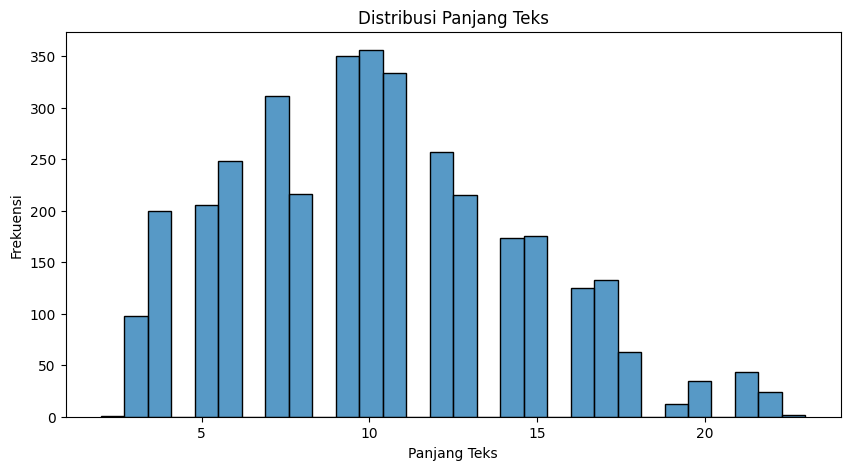

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df['text_length'], bins=30)

plt.title('Distribusi Panjang Teks')
plt.xlabel('Panjang Teks')
plt.ylabel('Frekuensi')

plt.show()

In [24]:
df.sort_values(
    by='text_length',
    ascending=False
)[['deskripsi_clean', 'text_length']].head(10)

,deskripsi_clean,text_length
2067,genesis crystal genshin,23
2196,genesis crystal genshin,23
237,produk perawatan kulit,22
340,produk perawatan kulit,22
657,produk perawatan kulit,22
316,produk perawatan kulit,22
2476,shampoo head shoulders,22
64,produk perawatan kulit,22
744,produk perawatan kulit,22
779,produk perawatan kulit,22


In [25]:
df.sort_values(
    by='text_length',
    ascending=True
)[['deskripsi_clean', 'text_length']].head(10)

,deskripsi_clean,text_length
3553,rs,2
3536,lrt,3
1272,air,3
3558,gym,3
3463,spp,3
3465,ukt,3
49,gas,3
1274,air,3
3443,jnt,3
2074,cgv,3


#### Insight

Analisis distribusi panjang teks menunjukkan bahwa mayoritas deskripsi transaksi bersifat sangat ringkas dengan rata-rata panjang 10.24 karakter dan median 10 karakter. Data memiliki rentang yang cukup sempit, yaitu antara 2 hingga 23 karakter. Sebagaimana terlihat, teks terpendek didominasi oleh singkatan atau istilah teknis seperti "rs", "lrt", dan "gym". Sementara itu, teks terpanjang mencapai batas maksimal melalui deskripsi seperti "genesis crystal genshin" dan "produk perawatan kulit". Karakteristik data yang pendek namun konsisten ini (dengan standar deviasi 4.22) mengindikasikan bahwa fitur tekstual dalam dataset ini sangat efisien untuk diproses oleh model NLP ringan, karena tidak memerlukan teknik padding atau truncation yang kompleks.

#### Most Common Words Analysis

In [26]:
all_words = ' '.join(df['deskripsi_clean'])

word_list = all_words.split()

from collections import Counter

common_words = Counter(word_list).most_common(20)

common_words_df = pd.DataFrame(
    common_words,
    columns=['word', 'count']
)

In [27]:
common_words = Counter(word_list).most_common(20)

common_words_df = pd.DataFrame(
    common_words,
    columns=['word', 'count']
)

common_words_df

,word,count
0,biaya,101
1,tiket,100
2,beli,90
3,makan,76
4,bayar,69
5,dokter,68
6,listrik,68
7,air,67
8,makanan,63
9,obat,62


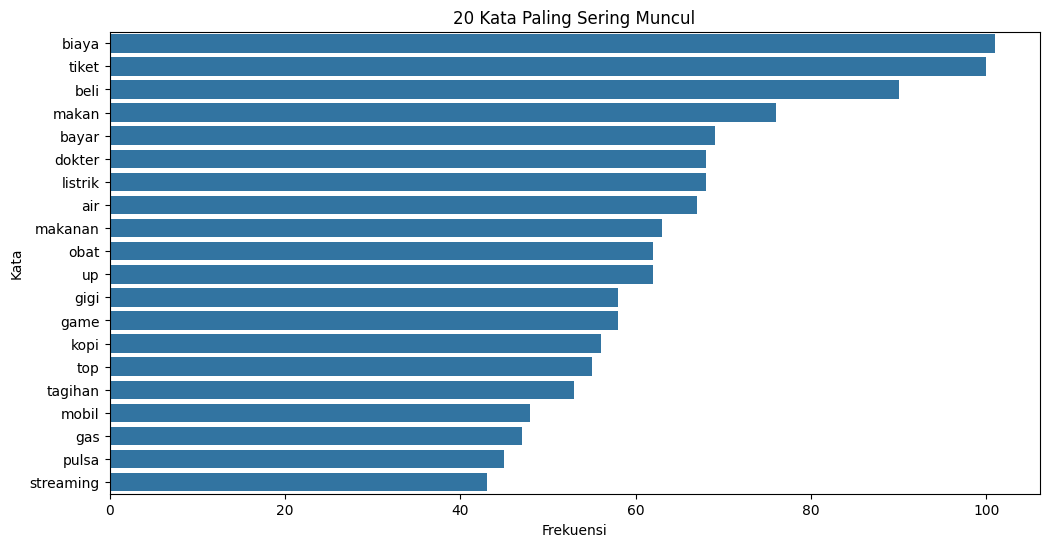

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_words_df,
    x='count',
    y='word'
)

plt.title('20 Kata Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')

plt.show()

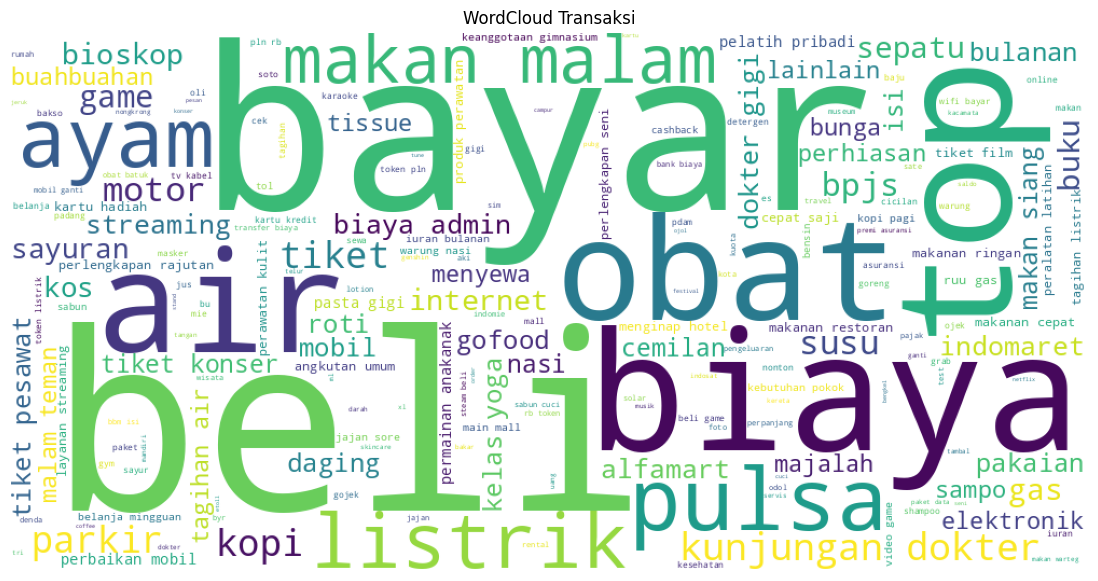

In [29]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Transaksi')

plt.show()

#### Insight

Berdasarkan analisis kata yang paling sering muncul pada deskripsi transaksi, terlihat bahwa kata seperti “biaya”, “tiket”, “beli”, “makan”, dan “bayar” mendominasi dataset. Hal ini menunjukkan bahwa sebagian besar transaksi pengguna berkaitan dengan kebutuhan sehari-hari, pembayaran tagihan, konsumsi makanan, serta aktivitas hiburan atau perjalanan. Selain itu, kemunculan kata seperti “dokter”, “obat”, “listrik”, “air”, dan “pulsa” mengindikasikan adanya variasi kategori transaksi yang cukup beragam, mulai dari kesehatan hingga utilitas. Insight ini menunjukkan bahwa dataset sudah memiliki pola kata yang relevan untuk membantu model klasifikasi dalam mengenali kategori transaksi berdasarkan deskripsi teks.

#### Category-Based Text Analysis

In [30]:
for category in df['category'].unique():

    print(f'\nKategori: {category}')

    text = ' '.join(
        df[df['category'] == category]['deskripsi_clean']
    )

    words = text.split()

    print(Counter(words).most_common(10))


Kategori: makanan
[('makanan', 63), ('kopi', 56), ('makan', 56), ('ayam', 41), ('nasi', 41), ('warung', 32), ('susu', 24), ('sayuran', 24), ('roti', 22), ('daging', 22)]

Kategori: hiburan
[('tiket', 60), ('game', 58), ('up', 56), ('top', 52), ('streaming', 43), ('perlengkapan', 40), ('konser', 25), ('buku', 25), ('bioskop', 25), ('seni', 24)]

Kategori: tagihan
[('listrik', 68), ('air', 59), ('tagihan', 53), ('biaya', 49), ('bayar', 46), ('pulsa', 45), ('bulanan', 38), ('admin', 35), ('iuran', 31), ('bpjs', 29)]

Kategori: kesehatan
[('dokter', 68), ('obat', 58), ('kunjungan', 40), ('gigi', 36), ('yoga', 25), ('kelas', 22), ('pelatih', 20), ('pribadi', 20), ('peralatan', 20), ('latihan', 20)]

Kategori: belanja
[('sabun', 41), ('belanja', 30), ('sepatu', 27), ('beli', 27), ('alfamart', 23), ('indomaret', 23), ('gigi', 22), ('pakaian', 22), ('hadiah', 22), ('bunga', 20)]

Kategori: transportasi
[('mobil', 44), ('tiket', 40), ('motor', 27), ('bensin', 26), ('isi', 24), ('pesawat', 22),

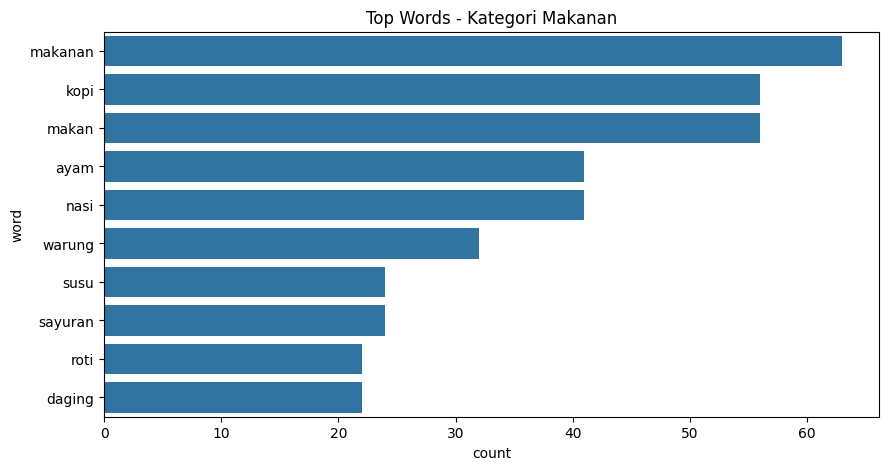

In [31]:
makanan_text = ' '.join(
    df[df['category']=='makanan']['deskripsi_clean']
)

makanan_words = makanan_text.split()

makanan_common = Counter(
    makanan_words
).most_common(10)

makanan_df = pd.DataFrame(
    makanan_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=makanan_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Makanan')

plt.show()

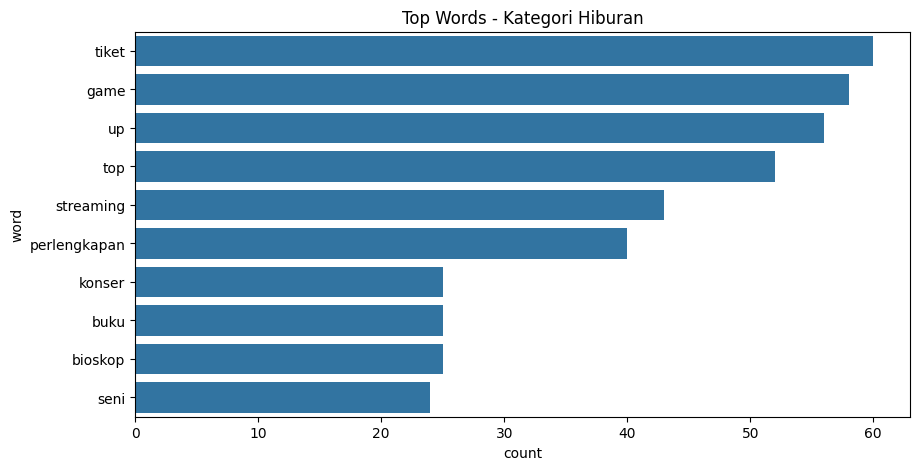

In [32]:
hiburan_text = ' '.join(
    df[df['category']=='hiburan']['deskripsi_clean']
)

hiburan_words = hiburan_text.split()

hiburan_common = Counter(
    hiburan_words
).most_common(10)

hiburan_df = pd.DataFrame(
    hiburan_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=hiburan_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Hiburan')

plt.show()

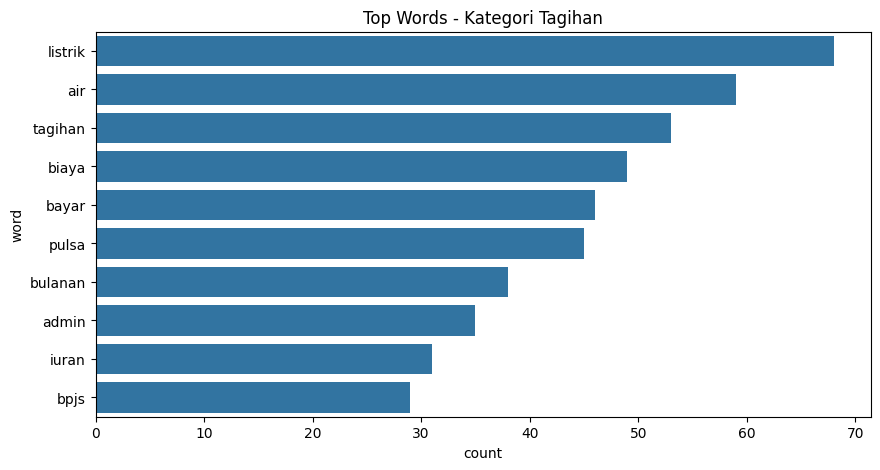

In [33]:
tagihan_text = ' '.join(
    df[df['category']=='tagihan']['deskripsi_clean']
)

tagihan_words = tagihan_text.split()

tagihan_common = Counter(
    tagihan_words
).most_common(10)

tagihan_df = pd.DataFrame(
    tagihan_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=tagihan_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Tagihan')

plt.show()

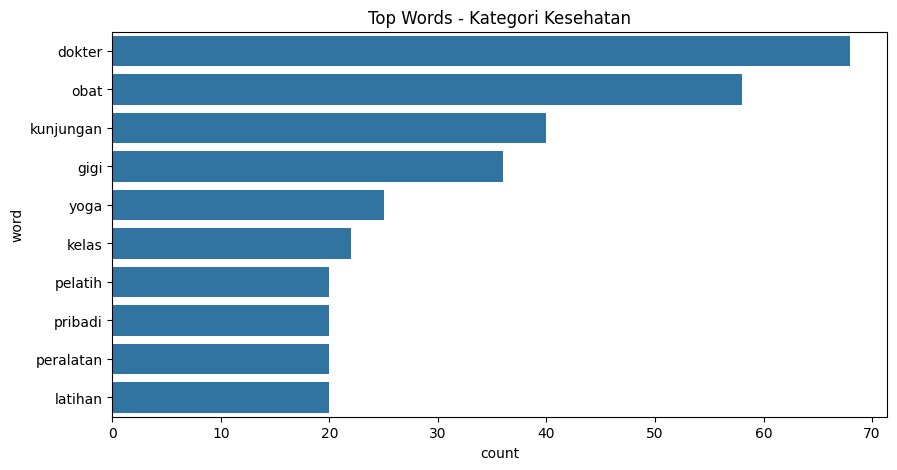

In [34]:
kesehatan_text = ' '.join(
    df[df['category']=='kesehatan']['deskripsi_clean']
)

kesehatan_words = kesehatan_text.split()

kesehatan_common = Counter(
    kesehatan_words
).most_common(10)

kesehatan_df = pd.DataFrame(
    kesehatan_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=kesehatan_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Kesehatan')

plt.show()

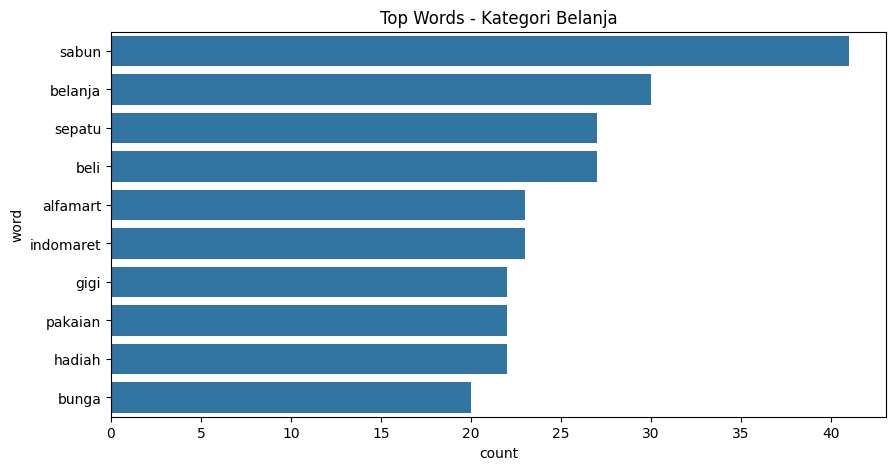

In [35]:
belanja_text = ' '.join(
    df[df['category']=='belanja']['deskripsi_clean']
)

belanja_words = belanja_text.split()

belanja_common = Counter(
    belanja_words
).most_common(10)

belanja_df = pd.DataFrame(
    belanja_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=belanja_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Belanja')

plt.show()

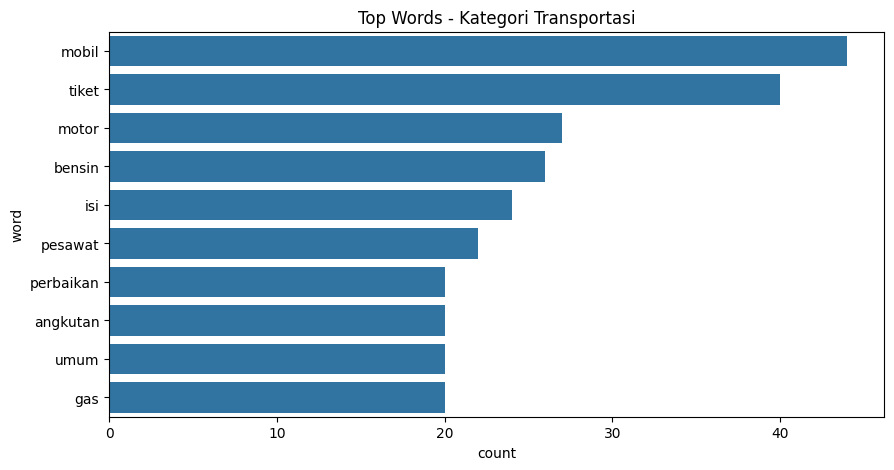

In [36]:
transportasi_text = ' '.join(
    df[df['category']=='transportasi']['deskripsi_clean']
)

transportasi_words = transportasi_text.split()

transportasi_common = Counter(
    transportasi_words
).most_common(10)

transportasi_df = pd.DataFrame(
    transportasi_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=transportasi_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Transportasi')

plt.show()

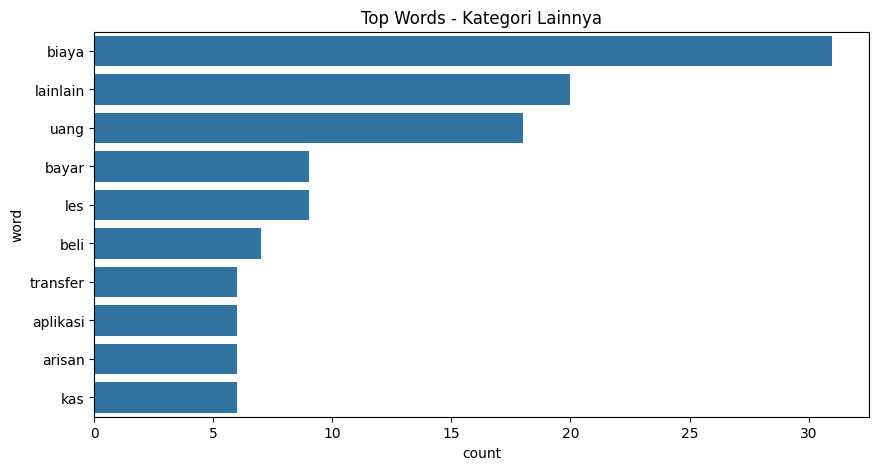

In [37]:
lainnya_text = ' '.join(
    df[df['category']=='lainnya']['deskripsi_clean']
)

lainnya_words = lainnya_text.split()

lainnya_common = Counter(
    lainnya_words
).most_common(10)

lainnya_df = pd.DataFrame(
    lainnya_common,
    columns=['word', 'count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=lainnya_df,
    x='count',
    y='word'
)

plt.title('Top Words - Kategori Lainnya')

plt.show()

#### N-Gram Analysis (Bi-grams & Tri-grams)

In [38]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

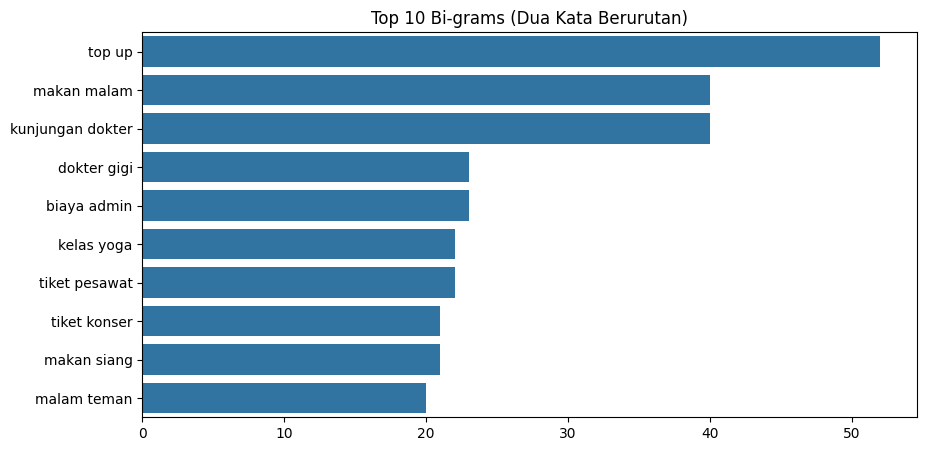

In [39]:
top_bi_grams = get_top_ngram(df['deskripsi_clean'], n=2)
x, y = map(list, zip(*top_bi_grams))
plt.figure(figsize=(10,5))
sns.barplot(x=y, y=x)
plt.title('Top 10 Bi-grams (Dua Kata Berurutan)')
plt.show()

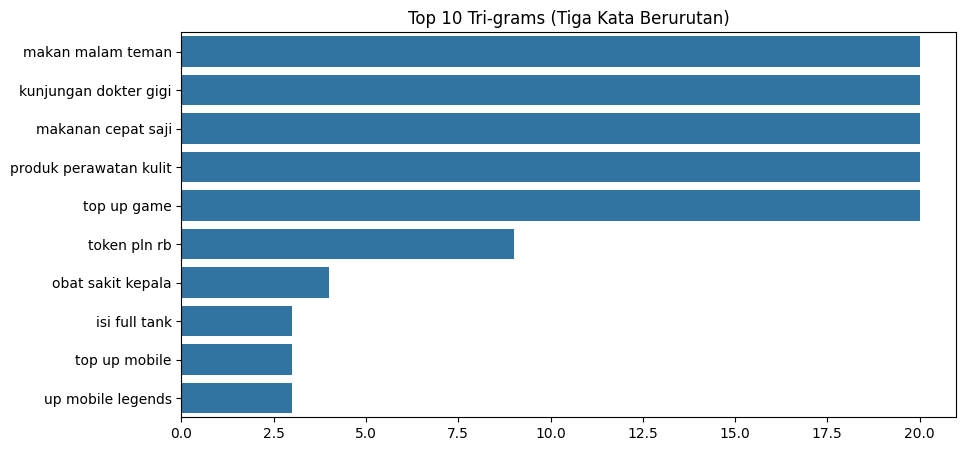

In [40]:
top_tri_grams = get_top_ngram(df['deskripsi_clean'], n=3)
x, y = map(list, zip(*top_tri_grams))
plt.figure(figsize=(10,5))
sns.barplot(x=y, y=x)
plt.title('Top 10 Tri-grams (Tiga Kata Berurutan)')
plt.show()

#### Insight

Berdasarkan analisis top words pada setiap kategori transaksi, terlihat bahwa setiap kategori memiliki pola kata yang cukup khas dan relevan dengan konteksnya. Kategori makanan didominasi kata seperti “makanan”, “kopi”, “ayam”, dan “nasi”, sedangkan kategori hiburan banyak mengandung kata “tiket”, “game”, “streaming”, dan “bioskop”. Pada kategori tagihan, kata seperti “listrik”, “air”, dan “pulsa” muncul paling sering, sementara kategori kesehatan didominasi oleh “dokter”, “obat”, dan “kunjungan”. Kategori belanja menunjukkan pola kata terkait kebutuhan sehari-hari seperti “sabun”, “sepatu”, dan nama minimarket, sedangkan kategori transportasi banyak memuat kata “mobil”, “motor”, dan “bensin”. Hasil ini menunjukkan bahwa dataset memiliki pemisahan karakteristik kata yang cukup jelas antar kategori, sehingga dapat membantu model machine learning dalam melakukan klasifikasi transaksi dengan lebih akurat.

## Transaction Frequency Analysis

In [41]:
category_freq = df['category'].value_counts()

category_freq

,count
category,
belanja,690
makanan,652
tagihan,594
hiburan,563
kesehatan,455
transportasi,423
lainnya,201


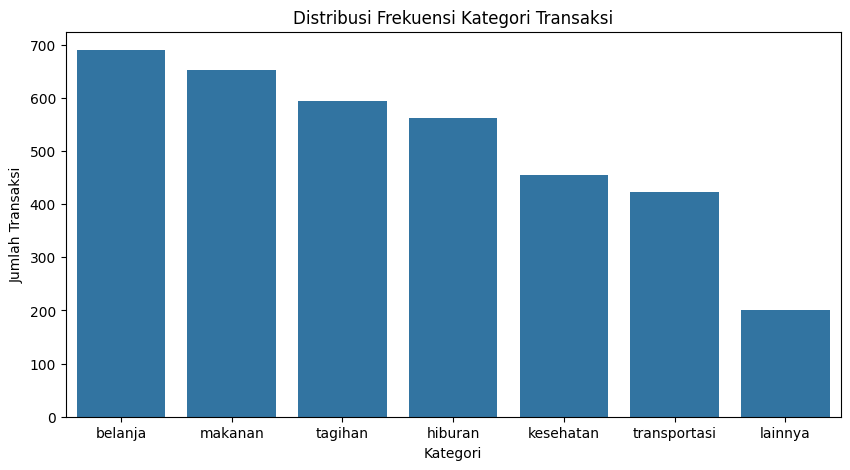

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_freq.index,
    y=category_freq.values
)

plt.title('Distribusi Frekuensi Kategori Transaksi')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Transaksi')

plt.show()

#### Insight

Berdasarkan distribusi frekuensi kategori transaksi, kategori belanja memiliki jumlah transaksi tertinggi sebanyak 690 data, diikuti oleh makanan dan tagihan. Hal ini menunjukkan bahwa aktivitas pengeluaran pengguna paling banyak berkaitan dengan kebutuhan sehari-hari dan konsumsi rutin. Sementara itu, kategori lainnya memiliki jumlah data paling sedikit dibanding kategori lain, yang mengindikasikan adanya ketidakseimbangan distribusi data antar kategori. Meskipun perbedaannya tidak terlalu ekstrem pada sebagian besar kategori, kondisi ini tetap perlu diperhatikan karena dapat memengaruhi performa model klasifikasi, terutama dalam memprediksi kategori dengan jumlah data yang lebih sedikit.

### Bigram Phrase Analysis

In [43]:
bigram = CountVectorizer(
    ngram_range=(2,2)
)

X = bigram.fit_transform(
    df['deskripsi_clean']
)

bigram_words = bigram.get_feature_names_out()

counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({
    'bigram': bigram_words,
    'count': counts
})

bigram_df = bigram_df.sort_values(
    by='count',
    ascending=False
)

bigram_df.head(20)

,bigram,count
681,top up,52
407,makan malam,40
380,kunjungan dokter,40
127,biaya admin,23
233,dokter gigi,23
358,kelas yoga,22
663,tiket pesawat,22
412,makan siang,21
660,tiket konser,21
73,belanja mingguan,20


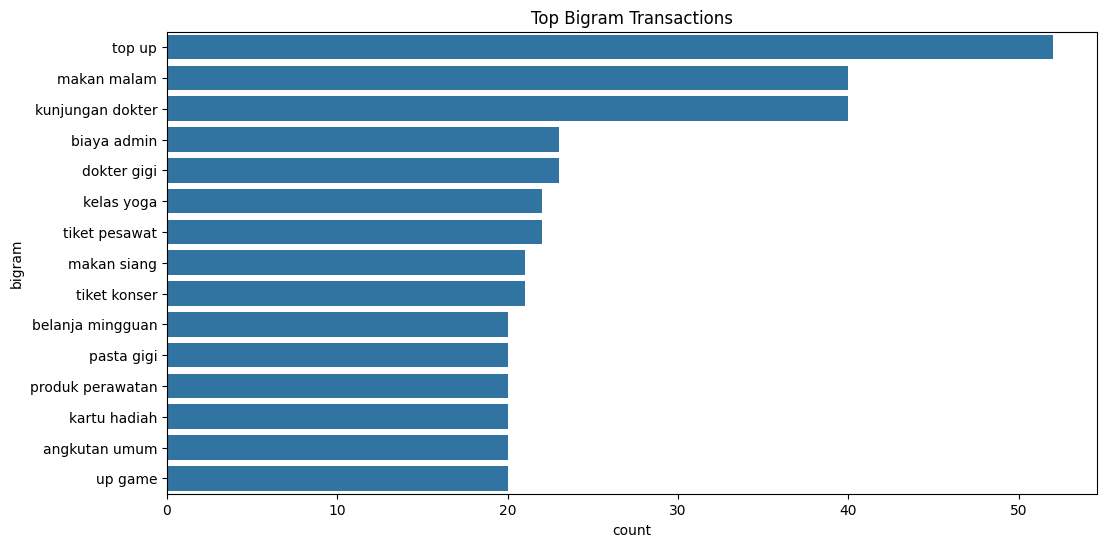

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bigram_df.head(15),
    x='count',
    y='bigram'
)

plt.title('Top Bigram Transactions')

plt.show()

#### Insight

Berdasarkan analisis bigram, terlihat bahwa kombinasi kata seperti “top up”, “makan malam”, dan “kunjungan dokter” merupakan frasa yang paling sering muncul pada deskripsi transaksi. Kemunculan bigram yang spesifik seperti “dokter gigi”, “kelas yoga”, “tiket pesawat”, dan “video game” menunjukkan bahwa pola transaksi pengguna memiliki konteks yang cukup jelas untuk merepresentasikan kategori tertentu. Insight ini menunjukkan bahwa penggunaan fitur bigram dapat membantu model memahami hubungan antar kata dengan lebih baik dibanding hanya menggunakan kata tunggal (unigram), sehingga berpotensi meningkatkan akurasi klasifikasi transaksi karena konteks transaksi menjadi lebih spesifik dan informatif.

### Ambiguous Word Analysis

In [45]:
word_category = {}

for category in df['category'].unique():

    text = ' '.join(
        df[df['category']==category]['deskripsi_clean']
    )

    words = set(text.split())

    for word in words:

        if word not in word_category:
            word_category[word] = []

        word_category[word].append(category)

ambiguous_words = {
    word: cats
    for word, cats in word_category.items()
    if len(cats) > 1
}

list(ambiguous_words.items())[:20]

[('susu', ['makanan', 'kesehatan']),
 ('tarik', ['makanan', 'tagihan']),
 ('ojek', ['makanan', 'transportasi']),
 ('makan', ['makanan', 'hiburan']),
 ('jajan', ['makanan', 'lainnya']),
 ('kapal', ['makanan', 'transportasi']),
 ('online', ['makanan', 'belanja', 'transportasi']),
 ('ojol', ['makanan', 'transportasi']),
 ('jiwa', ['makanan', 'tagihan']),
 ('pesan', ['makanan', 'transportasi']),
 ('api', ['makanan', 'transportasi']),
 ('malam', ['makanan', 'hiburan']),
 ('air', ['makanan', 'tagihan', 'transportasi']),
 ('nongkrong', ['makanan', 'hiburan']),
 ('minyak', ['makanan', 'kesehatan']),
 ('order', ['makanan', 'transportasi']),
 ('pagi', ['makanan', 'kesehatan']),
 ('putih', ['makanan', 'kesehatan']),
 ('gula', ['makanan', 'kesehatan']),
 ('beli',
  ['makanan',
   'hiburan',
   'tagihan',
   'kesehatan',
   'belanja',
   'transportasi',
   'lainnya'])]

#### Insight

Berdasarkan analisis kata yang muncul pada lebih dari satu kategori, terdapat beberapa kata ambigu seperti “air”, “online”, “beli”, “pesan”, dan “ojek” yang digunakan dalam konteks transaksi yang berbeda. Hal ini menunjukkan bahwa satu kata tidak selalu merepresentasikan satu kategori tertentu, sehingga konteks kalimat atau kombinasi kata menjadi penting dalam proses klasifikasi. Misalnya, kata “air” dapat merujuk pada tagihan utilitas maupun produk konsumsi, sedangkan “online” dapat muncul pada transaksi belanja maupun transportasi. Insight ini mengindikasikan bahwa model klasifikasi perlu mempertimbangkan konteks teks secara keseluruhan, seperti menggunakan bigram atau teknik NLP yang lebih kontekstual, agar mampu membedakan kategori transaksi dengan lebih akurat.

#### Analisis Ambiguitas Kategori (Label Overlap)

In [46]:
words_by_category = df.groupby('category')['deskripsi_clean'].apply(lambda x: ' '.join(x).split())
all_words = [word for words in words_by_category for word in set(words)]
word_counts = Counter(all_words)

# Cari kata yang muncul di lebih dari 3 kategori berbeda
ambiguous_words = [word for word, count in word_counts.items() if count > 3]

print(f"Kata-kata ambigu yang muncul di banyak kategori: {ambiguous_words}")

Kata-kata ambigu yang muncul di banyak kategori: ['biaya', 'beli', 'bayar']


#### Insight

Berdasarkan analisis ambiguitas kategori, ditemukan beberapa kata seperti “biaya”, “beli”, dan “bayar” yang muncul di banyak kategori transaksi. Hal ini menunjukkan bahwa kata-kata tersebut bersifat umum dan tidak cukup kuat untuk menjadi penentu kategori secara langsung. Kondisi ini dapat menyebabkan overlap antar kategori dan meningkatkan potensi kesalahan klasifikasi apabila model hanya bergantung pada kata tunggal. Oleh karena itu, diperlukan pemanfaatan konteks tambahan seperti kombinasi kata (bigram), TF-IDF, atau model NLP yang lebih kontekstual agar proses klasifikasi transaksi menjadi lebih akurat dan mampu membedakan makna kata berdasarkan konteks penggunaannya.

## Dataset Readiness Analysis

### Dataset Quality Assessment
#### Positif
- Dataset memiliki jumlah data yang cukup untuk pengembangan MVP transaction classifier.
- Distribusi kategori cukup seimbang meskipun kategori ‘lainnya’ memiliki jumlah data lebih sedikit.
- Sebagian besar kategori memiliki keyword yang spesifik dan konsisten.
- Missing value sangat sedikit dan berhasil ditangani.
- Dataset cukup representatif untuk pengembangan model klasifikasi kategori transaksi
#### Tantangan
- Dataset memiliki duplicate yang cukup tinggi (~70%).
- Variasi teks masih terbatas.
- Kategori “lainnya” cenderung ambigu.
- Beberapa phrase penting terpisah akibat preprocessing.

## NLP Characteristics Analysis

### Karakteristik Dataset NLP

Berdasarkan hasil EDA:

- Dataset termasuk short text classification.
- Transaksi bersifat keyword-based.
- Sebagian besar kategori memiliki kata dominan yang jelas.
- Context phrase seperti “top up” dan “tiket pesawat” penting untuk dipertahankan.

# Risk Assessment

### Risiko Dataset

#### Overfitting Risk
- Tingginya duplicate transaction berpotensi menyebabkan model menghafal keyword tertentu.

#### Ambiguous Category Risk
- Kategori “lainnya” memiliki keyword yang sangat umum sehingga berpotensi menyebabkan kesalahan klasifikasi.

#### Context Loss Risk
- Preprocessing saat ini memisahkan beberapa phrase penting seperti “top up”, yang dapat mengurangi pemahaman konteks model.

## Preprocessing Recommendation

### Rekomendasi Preprocessing
1. Gunakan N-Gram

   Disarankan menggunakan:

     `ngram_range=(1,2)`

   untuk mempertahankan context phrase seperti:
   - top up
   - tiket pesawat
   - makan malam

2. Pertimbangkan Stemming Improvement

   Karena kata seperti:
   - makan
   - makanan
   
   masih dianggap berbeda.

3. Gunakan Stratified Split

   Untuk menjaga distribusi kategori saat training dan testing.

4. Gunakan Validation Set

   Untuk mengurangi risiko overfitting akibat duplicate data.

# Model Recommendation

### Baseline Model Recommendation
#### TF-IDF + Logistic Regression
Alasan
- Cocok untuk short text classification
- Cepat dan ringan
- Efektif untuk keyword-based dataset
- Mudah dijadikan baseline evaluation
### Alternative Model Recommendation
#### TF-IDF + Linear SVM
Alasan
- Cocok untuk text classification
- Baik untuk sparse feature NLP
- Stabil untuk dataset ukuran menengah
### Advanced Model Recommendation
#### IndoBERT Fine-Tuning
Alasan
- Mampu memahami konteks bahasa Indonesia lebih baik
- Cocok jika dataset diperbesar dan dibuat lebih variatif

Risiko
- Overkill untuk dataset kecil
- Membutuhkan resource lebih besar
- Berpotensi overfitting

# Conclusion


Berdasarkan hasil Exploratory Data Analysis (EDA), dataset transaksi FinSight memiliki karakteristik** short text transaction** classification dengan distribusi kategori yang relatif seimbang dan sebagian besar transaksi terdiri dari deskripsi singkat berbasis keyword. Setiap kategori utama menunjukkan pola kata yang cukup spesifik dan konsisten sehingga mendukung proses klasifikasi transaksi secara otomatis.

Hasil analisis menunjukkan bahwa mayoritas transaksi **bersifat keyword-based**, di mana kata tertentu memiliki hubungan kuat terhadap kategori tertentu, seperti kata “listrik” pada kategori tagihan, “kopi” pada kategori makanan, dan “bensin” pada kategori transportasi. Oleh karena itu, pendekatan machine learning berbasis **TF-IDF dan classifier linear seperti Logistic Regression atau Linear SVM dinilai sesuai** sebagai baseline model untuk pengembangan MVP transaction classifier.

Selain itu, analisis bigram menunjukkan bahwa konteks phrase memiliki peran penting dalam memahami kategori transaksi. Phrase seperti “top up”, “tiket pesawat”, “makan malam”, dan “kunjungan dokter” memberikan representasi kategori yang lebih kuat dibanding token tunggal. Berdasarkan temuan tersebut, penggunaan **n-gram direkomendasikan** untuk mempertahankan konteks semantic transaksi selama proses feature extraction.

Analisis per kategori juga menunjukkan bahwa **enam kategori utama pada dataset memiliki keyword yang relatif jelas** dan cukup separable untuk mendukung proses klasifikasi otomatis. Sementara itu, kategori “lainnya” memiliki tingkat ambiguity dan variasi transaksi yang lebih tinggi dibanding kategori lain sehingga lebih sesuai digunakan sebagai fallback category untuk transaksi yang tidak dapat direpresentasikan secara jelas oleh kategori utama.

In [47]:
df.to_csv(
    'dataset_eda_final.csv',
    index=False
)